In [1]:
import os
import sys
import random
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical

import pandas as pd
import matplotlib.pyplot as plt

from rl_env import NurseDispatchEnv

print("PyTorch version:", torch.__version__)
print("Current folder:", Path.cwd())

env = NurseDispatchEnv()
obs = env.reset(seed=1)

print("Observation size:", len(obs))
print("Action space size:", env.action_space_size)
print("Initial observation:")
print(obs)

PyTorch version: 2.5.1+cu121
Current folder: C:\Users\lny\Desktop\Research project\2D Caregiving Simulation\python_sim
Observation size: 20
Action space size: 5
Initial observation:
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


In [2]:
class ActorCritic(nn.Module):
    def __init__(self, observation_size, action_size):
        super().__init__()

        self.shared = nn.Sequential(
            nn.Linear(observation_size, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU()
        )

        self.actor = nn.Linear(128, action_size)
        self.critic = nn.Linear(128, 1)

    def forward(self, x):
        features = self.shared(x)
        logits = self.actor(features)
        value = self.critic(features)
        return logits, value


model = ActorCritic(
    observation_size=env.observation_size,
    action_size=env.action_space_size
)

test_obs = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)
logits, value = model(test_obs)

print("Logits:", logits)
print("Value:", value)
print("Action probabilities:", torch.softmax(logits, dim=-1))

Logits: tensor([[ 0.0139, -0.0354, -0.1083, -0.1283, -0.0196]],
       grad_fn=<AddmmBackward0>)
Value: tensor([[0.0334]], grad_fn=<AddmmBackward0>)
Action probabilities: tensor([[0.2141, 0.2038, 0.1895, 0.1857, 0.2070]], grad_fn=<SoftmaxBackward0>)


In [3]:
class PPOAgent:
    def __init__(
        self,
        observation_size,
        action_size,
        lr=3e-4,
        gamma=0.99,
        clip_epsilon=0.2,
        update_epochs=4
    ):
        self.gamma = gamma
        self.clip_epsilon = clip_epsilon
        self.update_epochs = update_epochs

        self.model = ActorCritic(observation_size, action_size)
        self.optimizer = optim.Adam(self.model.parameters(), lr=lr)

    def select_action(self, obs):
        obs_tensor = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)

        logits, value = self.model(obs_tensor)
        dist = Categorical(logits=logits)

        action = dist.sample()
        log_prob = dist.log_prob(action)

        return action.item(), log_prob.squeeze(), value.squeeze()

    def update(self, observations, actions, old_log_probs, returns, advantages):
        observations = torch.tensor(observations, dtype=torch.float32)
        actions = torch.tensor(actions, dtype=torch.long)
        old_log_probs = torch.stack(old_log_probs).detach()
        returns = torch.tensor(returns, dtype=torch.float32)
        advantages = torch.tensor(advantages, dtype=torch.float32)

        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        for _ in range(self.update_epochs):
            logits, values = self.model(observations)
            values = values.squeeze()

            dist = Categorical(logits=logits)
            new_log_probs = dist.log_prob(actions)
            entropy = dist.entropy().mean()

            ratio = torch.exp(new_log_probs - old_log_probs)

            clipped_ratio = torch.clamp(
                ratio,
                1.0 - self.clip_epsilon,
                1.0 + self.clip_epsilon
            )

            actor_loss = -torch.min(
                ratio * advantages,
                clipped_ratio * advantages
            ).mean()

            critic_loss = nn.MSELoss()(values, returns)

            loss = actor_loss + 0.5 * critic_loss - 0.01 * entropy

            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()


def compute_returns_and_advantages(rewards, values, gamma):
    returns = []
    discounted_return = 0

    for reward in reversed(rewards):
        discounted_return = reward + gamma * discounted_return
        returns.insert(0, discounted_return)

    advantages = [
        returns[i] - values[i].item()
        for i in range(len(rewards))
    ]

    return returns, advantages


agent = PPOAgent(
    observation_size=env.observation_size,
    action_size=env.action_space_size
)

print("PPO agent created.")

PPO agent created.


In [4]:
def run_one_episode(env, agent, seed=1, train=False):
    obs = env.reset(seed=seed)

    observations = []
    actions = []
    log_probs = []
    values = []
    rewards = []

    done = False
    total_reward = 0
    final_info = {}

    while not done:
        action, log_prob, value = agent.select_action(obs)

        next_obs, reward, done, info = env.step(action)

        observations.append(obs)
        actions.append(action)
        log_probs.append(log_prob)
        values.append(value)
        rewards.append(reward)

        obs = next_obs
        total_reward += reward

        if done:
            final_info = info

    if train:
        returns, advantages = compute_returns_and_advantages(
            rewards,
            values,
            agent.gamma
        )

        agent.update(
            observations,
            actions,
            log_probs,
            returns,
            advantages
        )

    return {
        "total_reward": total_reward,
        "steps": len(rewards),
        "completed_tasks": final_info.get("completed_tasks", 0),
        "completion_rate": final_info.get("completion_rate", 0),
        "average_waiting_time_min": final_info.get("average_waiting_time", 0) / 60,
        "p95_waiting_time_min": final_info.get("p95_waiting_time", 0) / 60,
        "escalations": final_info.get("escalations", 0),
        "total_distance": final_info.get("total_distance", 0),
        "average_fatigue": final_info.get("average_fatigue", 0),
        "workload_std": final_info.get("workload_std", 0),
        "normal_workload_std": final_info.get("normal_workload_std", 0),
        "distance_std": final_info.get("distance_std", 0),
        "final_fatigue_std": final_info.get("final_fatigue_std", 0),
    }


test_result = run_one_episode(env, agent, seed=1, train=False)

test_result

{'total_reward': 1713.0147348029095,
 'steps': 500,
 'completed_tasks': 143,
 'completion_rate': 0.934640522875817,
 'average_waiting_time_min': 1.596969696969697,
 'p95_waiting_time_min': 7.15,
 'escalations': 9,
 'total_distance': 9063.230986549666,
 'average_fatigue': 0.029111387222222663,
 'workload_std': 2.228601953392904,
 'normal_workload_std': 2.228601953392904,
 'distance_std': 147.77520883116577,
 'final_fatigue_std': 0.08804817368287217}

In [5]:
num_episodes = 300

training_logs = []

for episode in range(1, num_episodes + 1):
    seed = episode

    result = run_one_episode(
        env=env,
        agent=agent,
        seed=seed,
        train=True
    )

    result["episode"] = episode
    result["seed"] = seed

    training_logs.append(result)

    print(
        f"Episode {episode:03d} | "
        f"Reward={result['total_reward']:.2f} | "
        f"Completed={result['completed_tasks']} | "
        f"AvgWait={result['average_waiting_time_min']:.2f} min | "
        f"P95={result['p95_waiting_time_min']:.2f} min | "
        f"Esc={result['escalations']} | "
        f"Completion={result['completion_rate'] * 100:.1f}%"
    )

print("Training finished.")

Episode 001 | Reward=1660.37 | Completed=138 | AvgWait=1.61 min | P95=7.07 min | Esc=7 | Completion=90.2%
Episode 002 | Reward=1197.42 | Completed=120 | AvgWait=3.48 min | P95=14.85 min | Esc=46 | Completion=90.9%
Episode 003 | Reward=1487.97 | Completed=131 | AvgWait=1.97 min | P95=9.42 min | Esc=22 | Completion=91.6%
Episode 004 | Reward=1111.94 | Completed=121 | AvgWait=3.52 min | P95=14.77 min | Esc=60 | Completion=89.0%
Episode 005 | Reward=1238.99 | Completed=116 | AvgWait=2.48 min | P95=10.87 min | Esc=34 | Completion=89.2%
Episode 006 | Reward=1159.39 | Completed=123 | AvgWait=4.07 min | P95=11.57 min | Esc=60 | Completion=87.2%
Episode 007 | Reward=1291.89 | Completed=128 | AvgWait=3.37 min | P95=10.07 min | Esc=55 | Completion=92.1%
Episode 008 | Reward=976.19 | Completed=117 | AvgWait=6.37 min | P95=20.68 min | Esc=80 | Completion=91.4%
Episode 009 | Reward=1183.44 | Completed=121 | AvgWait=4.77 min | P95=11.08 min | Esc=57 | Completion=89.0%
Episode 010 | Reward=1211.41 | C

In [6]:
output_dir = Path("outputs/ppo")
output_dir.mkdir(parents=True, exist_ok=True)

df_logs = pd.DataFrame(training_logs)
log_path = output_dir / "ppo_v3_training_log.csv"

df_logs.to_csv(log_path, index=False)

log_path

WindowsPath('outputs/ppo/ppo_v3_training_log.csv')

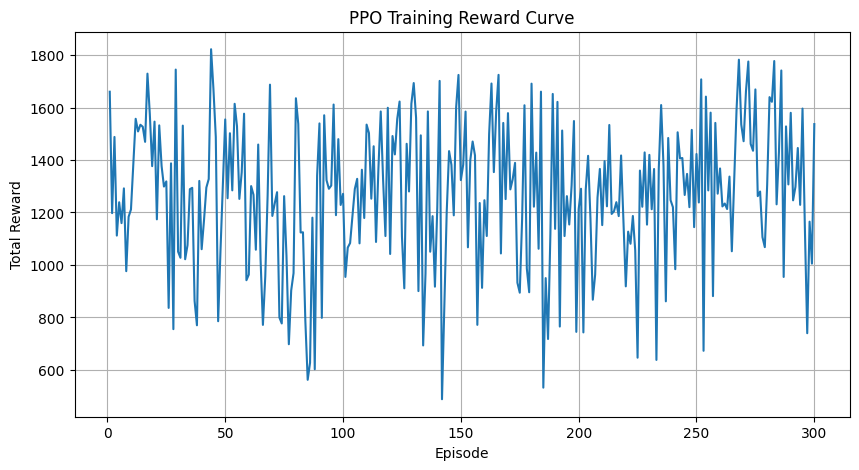

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(df_logs["episode"], df_logs["total_reward"])
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("PPO Training Reward Curve")
plt.grid(True)
plt.show()

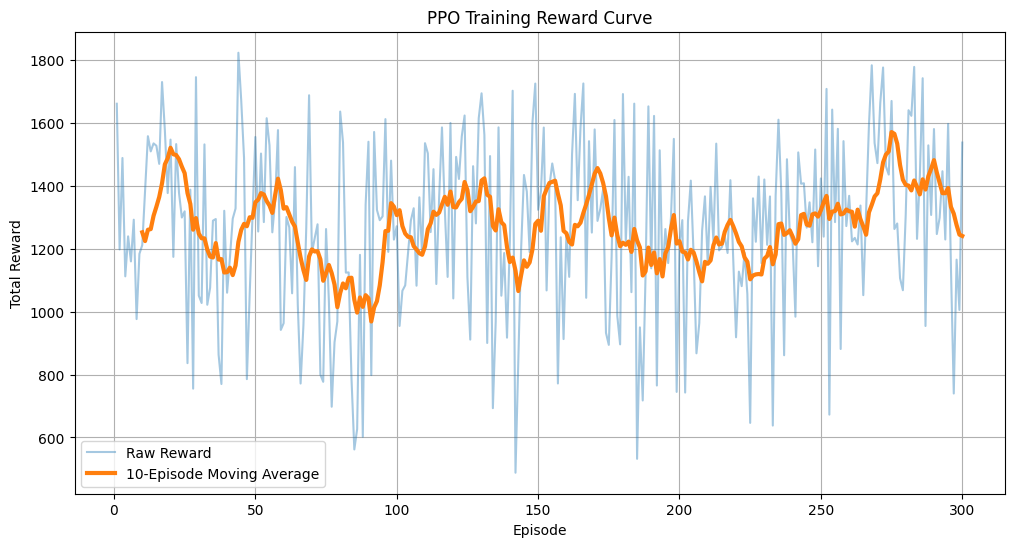

In [8]:
window = 10

df_logs["reward_ma"] = (
    df_logs["total_reward"]
    .rolling(window=window)
    .mean()
)

plt.figure(figsize=(12, 6))

plt.plot(
    df_logs["episode"],
    df_logs["total_reward"],
    alpha=0.4,
    label="Raw Reward"
)

plt.plot(
    df_logs["episode"],
    df_logs["reward_ma"],
    linewidth=3,
    label=f"{window}-Episode Moving Average"
)

plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("PPO Training Reward Curve")
plt.legend()
plt.grid(True)

plt.show()

In [9]:
output_dir = Path("outputs/ppo")
output_dir.mkdir(parents=True, exist_ok=True)

model_path = output_dir / "ppo_v3_model.pt"

torch.save(agent.model.state_dict(), model_path)

print("Model saved to:", model_path)

Model saved to: outputs\ppo\ppo_v3_model.pt


In [10]:
from pathlib import Path

plot_dir = Path("outputs/ppo/plots")
plot_dir.mkdir(parents=True, exist_ok=True)

plot_dir

WindowsPath('outputs/ppo/plots')

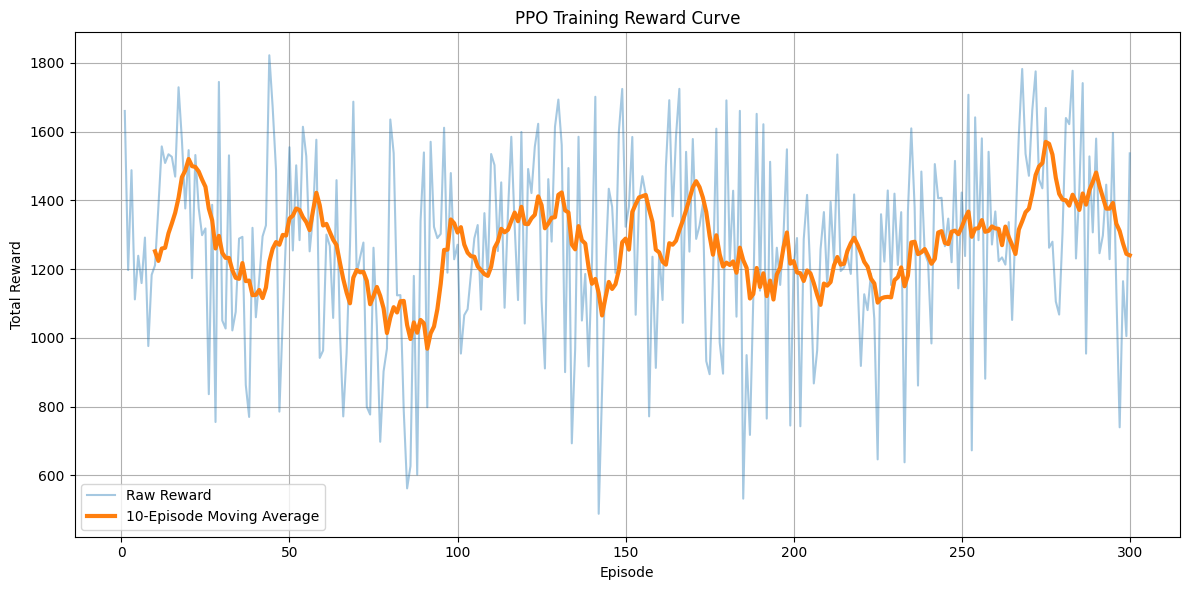

Saved: outputs\ppo\plots\ppo_v3_reward_curve.png


In [11]:
plt.figure(figsize=(12, 6))

plt.plot(
    df_logs["episode"],
    df_logs["total_reward"],
    alpha=0.4,
    label="Raw Reward"
)

df_logs["reward_ma_10"] = df_logs["total_reward"].rolling(window=10).mean()

plt.plot(
    df_logs["episode"],
    df_logs["reward_ma_10"],
    linewidth=3,
    label="10-Episode Moving Average"
)

plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("PPO Training Reward Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()

save_path = plot_dir / "ppo_v3_reward_curve.png"
plt.savefig(save_path, dpi=300)
plt.show()

print("Saved:", save_path)

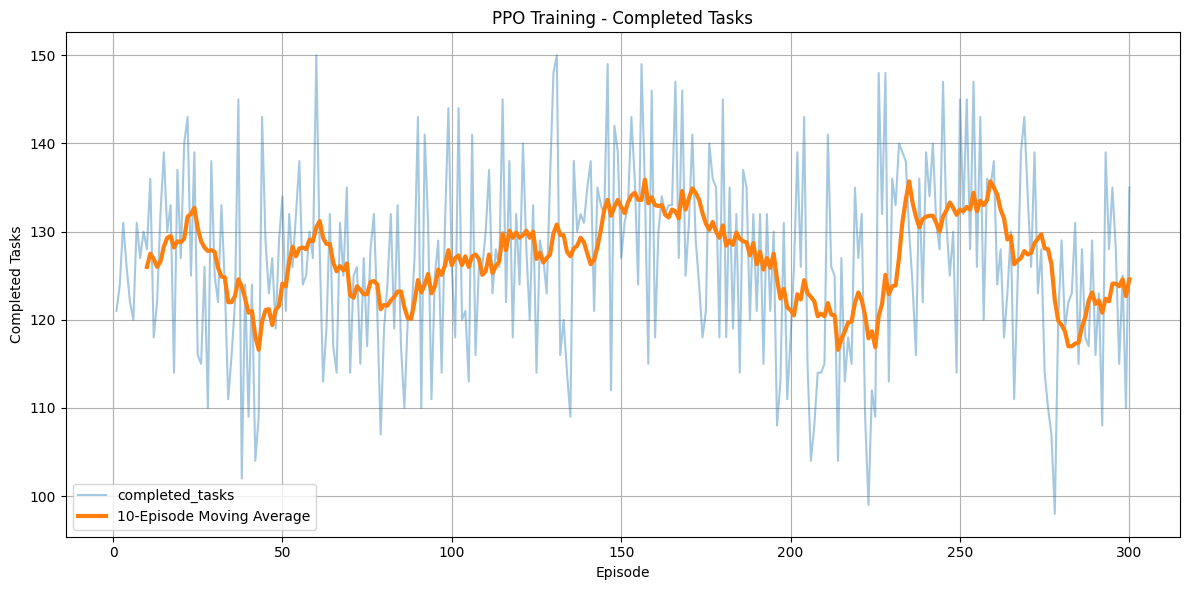

Saved: outputs\ppo\plots\ppo_training_completed_tasks.png


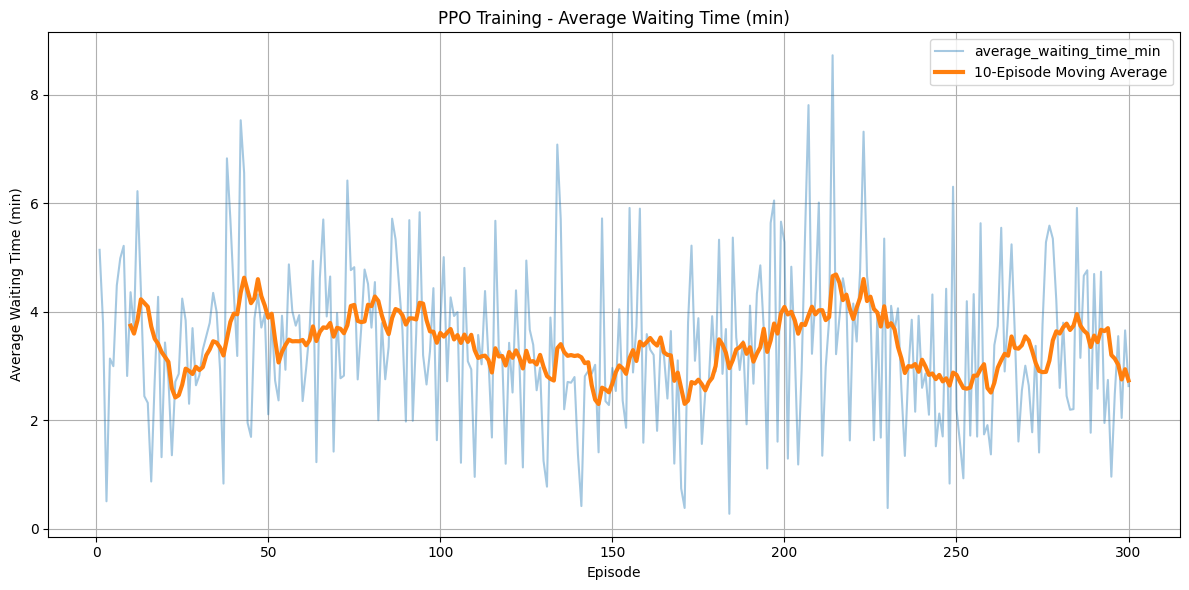

Saved: outputs\ppo\plots\ppo_training_average_waiting_time_min.png


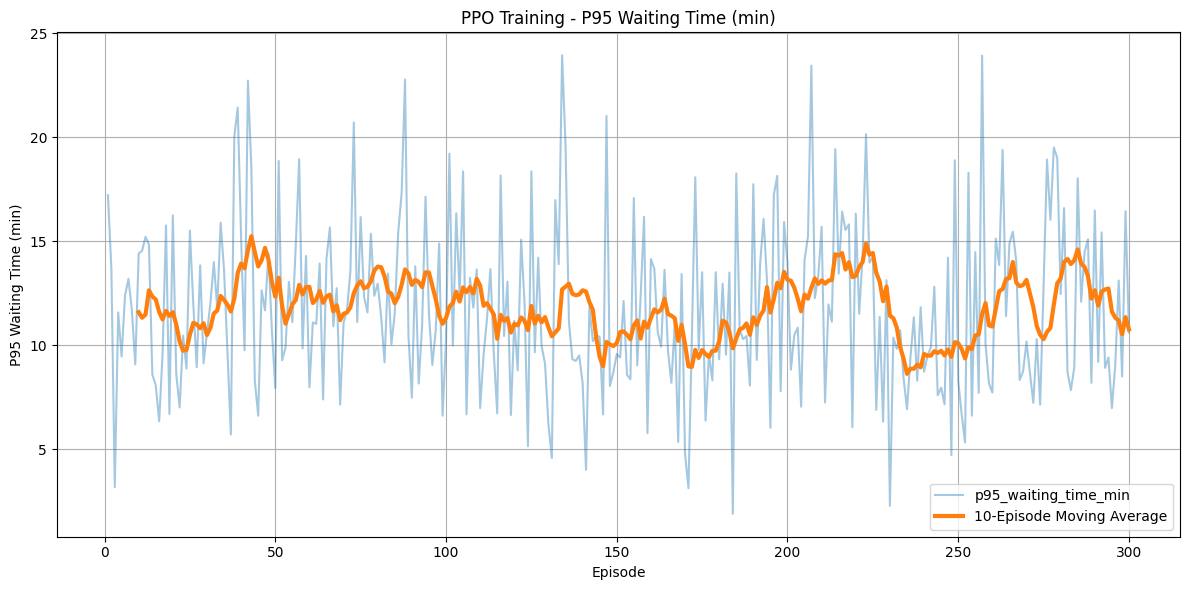

Saved: outputs\ppo\plots\ppo_training_p95_waiting_time_min.png


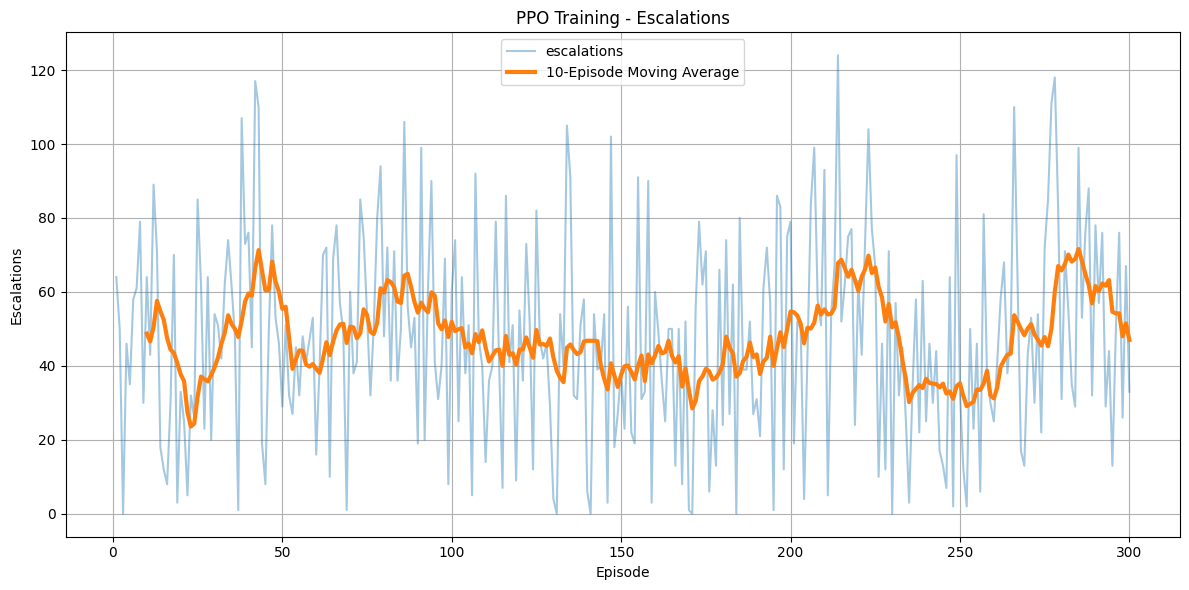

Saved: outputs\ppo\plots\ppo_training_escalations.png


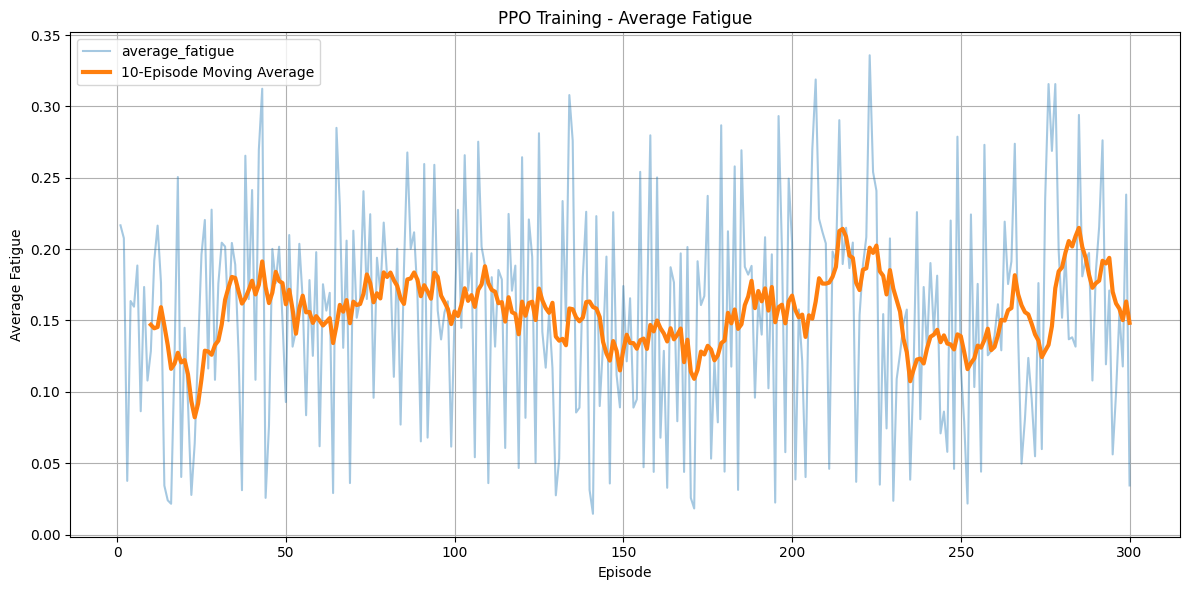

Saved: outputs\ppo\plots\ppo_training_average_fatigue.png


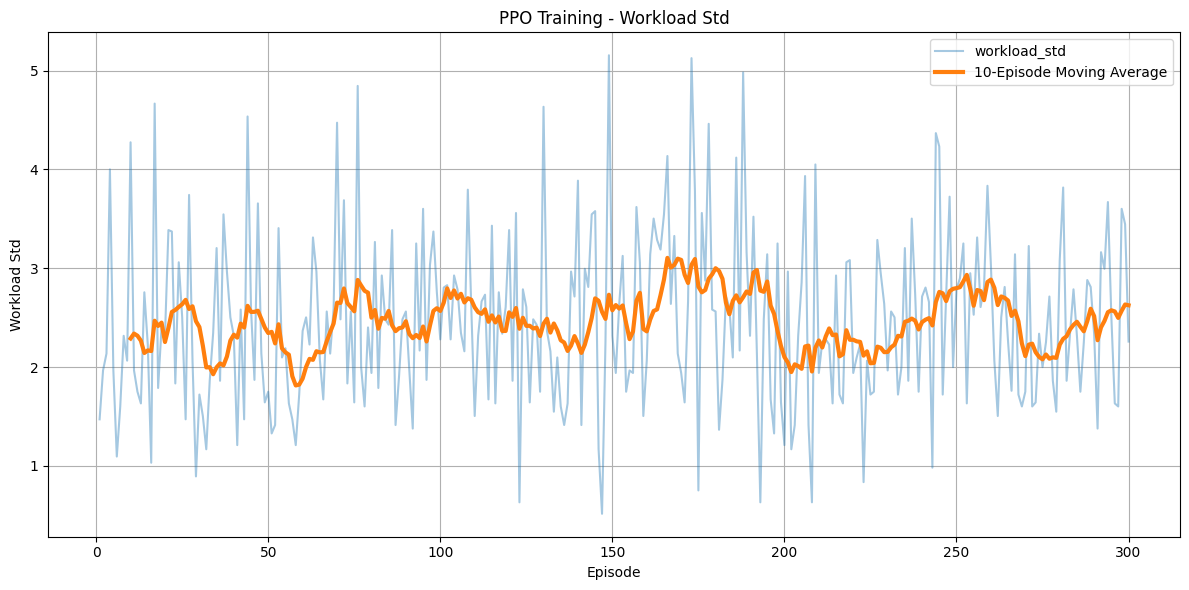

Saved: outputs\ppo\plots\ppo_training_workload_std.png


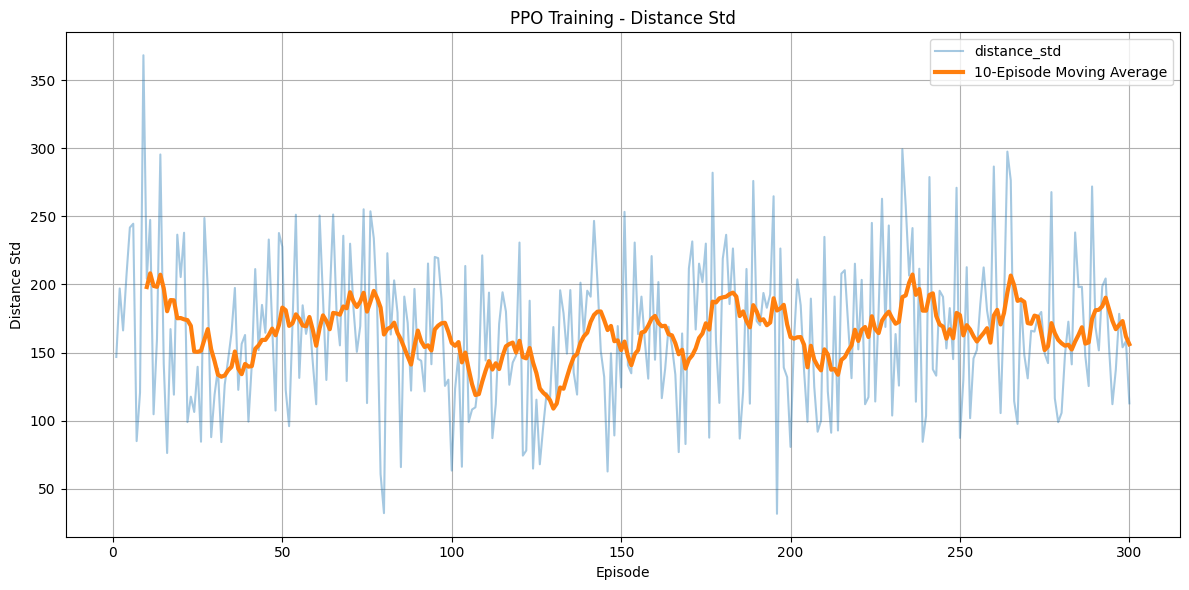

Saved: outputs\ppo\plots\ppo_training_distance_std.png


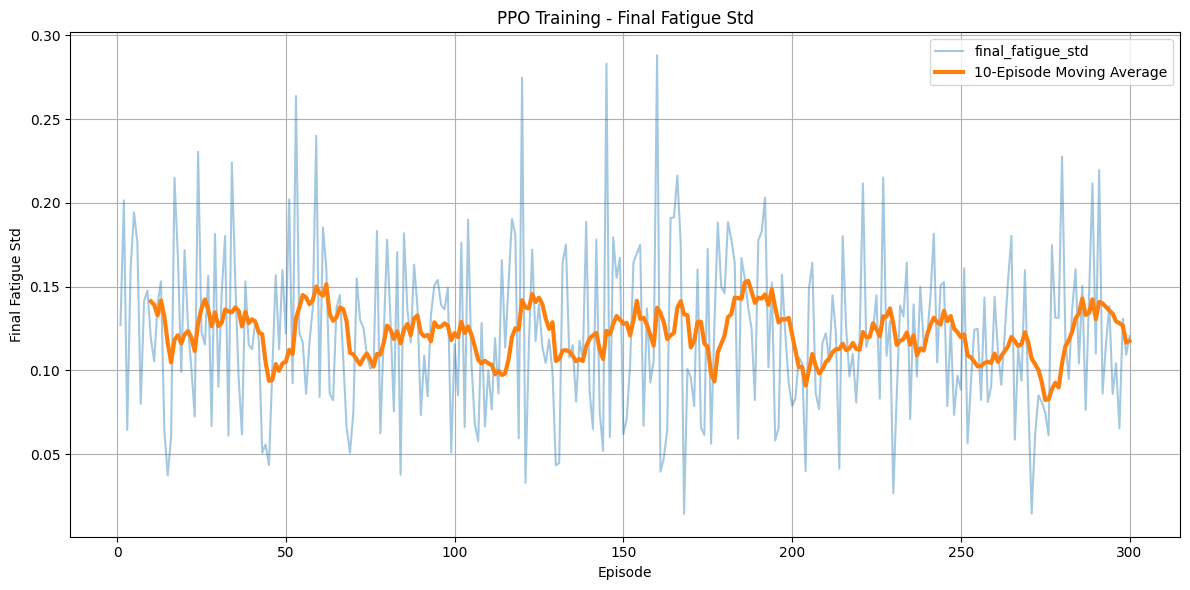

Saved: outputs\ppo\plots\ppo_training_final_fatigue_std.png


In [12]:
metrics_to_plot = [
    ("completed_tasks", "Completed Tasks"),
    ("average_waiting_time_min", "Average Waiting Time (min)"),
    ("p95_waiting_time_min", "P95 Waiting Time (min)"),
    ("escalations", "Escalations"),
    ("average_fatigue", "Average Fatigue"),
    ("workload_std", "Workload Std"),
    ("distance_std", "Distance Std"),
    ("final_fatigue_std", "Final Fatigue Std")
]

for metric, title in metrics_to_plot:
    plt.figure(figsize=(12, 6))

    plt.plot(
        df_logs["episode"],
        df_logs[metric],
        alpha=0.4,
        label=metric
    )

    ma_col = f"{metric}_ma_10"
    df_logs[ma_col] = df_logs[metric].rolling(window=10).mean()

    plt.plot(
        df_logs["episode"],
        df_logs[ma_col],
        linewidth=3,
        label="10-Episode Moving Average"
    )

    plt.xlabel("Episode")
    plt.ylabel(title)
    plt.title(f"PPO Training - {title}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    file_name = f"ppo_v3_training_{metric}.png"
    save_path = plot_dir / file_name
    plt.savefig(save_path, dpi=300)
    plt.show()

    print("Saved:", save_path)